# Explore TopicForest Outputs in Jupyter Notebook
We made TopicForest results easy to integrate with existing visualization platforms and packages, such as MedViz or DataMapPlot. This notebook demonstrates how to transform and visualize TopicForest outputs using DataMapPlot.

In [ ]:
# make sure to install the following packages
!pip install datamapplot
!pip install ipywidgets

In [1]:
# import the necessary libraries
import datamapplot
import pandas as pd
import json

## Load & Transform TopicForest Outputs

In [2]:
def parse_topic_json(topic_json):
    """ 
    Parse the topic_json to a dictionary of topic names
    """
    num_levels = len(topic_json["levels"])
    topic_dict = {}
    # loop through each level
    for level in topic_json["levels"]:
            # loop through each topic in the level
            for topic in level["topics"]:
                # add the topic name to the dictionary
                topic_dict[topic["global_topic_key"]] = topic["name"]
    return num_levels, topic_dict

topic_json = json.load(open("../bio_scirep/24k_abstracts.topics.json"))
num_levels, topic_dict = parse_topic_json(topic_json)

In [3]:
df = pd.read_csv("../bio_scirep/24k_abstracts.tsv", sep="\t")
df_cluster_assignments = pd.read_csv("../bio_scirep/24k_abstracts.cluster_assignments.tsv", sep="\t")

# transform the data into the format required by the datamapplot
hover_data_array = df.title.to_numpy()
data_map_array = df[["x", "y"]].to_numpy()
label_layers = []
for level in range(num_levels):
    label_layers.append(df_cluster_assignments[f"L{level}_clusters"].apply(lambda x: topic_dict[f"L{level}_{x}"]).to_numpy())

## Visualize 
- Zoom in/out to explore the hierarchical topic labels
- Hover over a point to view the article title
- Use the search bar to find topics or articles by keyword

Note: for more information on the parameters, please refer to the documentation: https://datamapplot.readthedocs.io/en/latest/interactive_intro.html

<InteractiveFigure width=100% height=800>
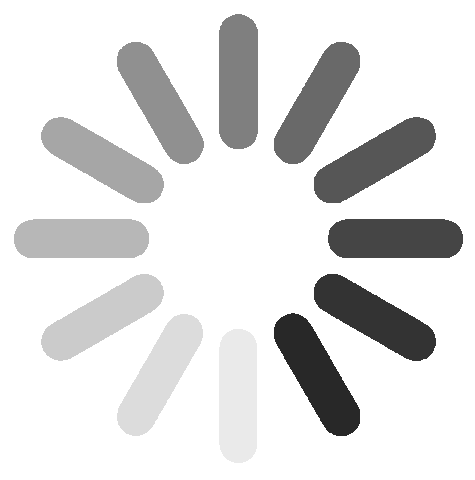

In [4]:
# create the interactive plot using the datamapplot
plot = datamapplot.create_interactive_plot(
    data_map_array,
    label_layers[0],
    label_layers[1],
    label_layers[2],
    hover_text = hover_data_array,
    font_family="Playfair Display SC",
    title="24K Biological Scirep Papers",
    enable_search=True
)
plot